In [1]:
# Install shap
# %pip install shap xgboost ucimlrepo

In [2]:
# Import
import os
import pandas as pd
import math
import time

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier

# preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# Plotting
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import shap

# dataset loading
import pickle
from ucimlrepo import fetch_ucirepo



# setup
# os.environ['LOKY_MAX_CPU_COUNT'] = '4'
RANDOM_SEED = 42


# Seaborn global styling
sns.set(style="whitegrid")

### Dataset Loading

In [3]:
# define pickle to load CIFAR Datasets
def unpickle(file):
    with open(file, "rb") as fo:
        d = pickle.load(fo, encoding="bytes")
    return d


In [4]:
# Load Breast Cancer Dataset from UCI

bc = fetch_ucirepo(id=17)
X_bc = bc.data.features.copy()
y_bc = bc.data.targets.copy()

X_bc.shape


# convert target
y_bc = y_bc.iloc[:, 0]  # select first column
y_bc = y_bc.map({"B": 0, "M": 1}).astype(int)

#Preprocessing
num_cols = X_bc.columns.tolist()

scaler = StandardScaler()
X_bc[num_cols] = scaler.fit_transform(X_bc[num_cols])

X_bc.shape, y_bc.shape


((569, 30), (569,))

In [5]:
# Load Bank Marketing Datasets from UCI and preprocessing
bank = fetch_ucirepo(id=222)
X_bank = bank.data.features.copy()
y_bank = bank.data.targets.copy()


# convert target yes/no
y_bank = y_bank.iloc[:, 0]               
y_bank = y_bank.map({"no": 0, "yes": 1}) 
y_bank = y_bank.astype(int)


#Replace unknown with NaN
X_bank = X_bank.replace("unknown", np.nan)

#Checking Missing Value
print(X_bank.isna().sum())

# Seperate numeric and categories columns
num_cols = X_bank.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_bank.select_dtypes(include=["object", "category"]).columns.tolist()

num_cols, cat_cols


# Cleaning 
# Imputation using mean 
if len(num_cols) > 0:
    num_imputer = SimpleImputer(strategy="mean")
    X_bank[num_cols] = num_imputer.fit_transform(X_bank[num_cols])

# Using Mode
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_bank[cat_cols] = cat_imputer.fit_transform(X_bank[cat_cols])

# Preprocessing

# One Hot Encoding
X_bank = pd.get_dummies(X_bank, columns=cat_cols, drop_first=False)

# Scaling
if len(num_cols) > 0:
    scaler = StandardScaler()
    X_bank[num_cols] = scaler.fit_transform(X_bank[num_cols])


X_bank.shape, y_bank.shape

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64


((45211, 47), (45211,))

In [6]:

# Load CIFAR from the path, scale it and transform to Dataframe
ROOT_DIR = "cifar-10-batches-py" 
N_SAMPLES = 1000                    
APPLY_PCA = False                  
PCA_COMPONENTS = 256


data_list = []
labels_list = []


# Loop through the 5 data batches provided in CIFAR-10
for i in range(1, 6):
    batch_name = f"data_batch_{i}"
    batch_path = os.path.join(ROOT_DIR, batch_name)
    
    # Check if file exists before trying to load
    if not os.path.exists(batch_path):
        print(f"Warning: {batch_path} not found. Skipping.")
        continue
        
    batch_dict = unpickle(batch_path)
    
    data_batch = batch_dict[b"data"]       
    labels_batch = batch_dict[b"labels"]

    data_list.append(data_batch)
    labels_list.extend(labels_batch)

# Stack them into single arrays

X_cifar = np.vstack(data_list)              
y_cifar = np.array(labels_list, dtype=int)
print("Raw CIFAR X shape:", X_cifar.shape)


if N_SAMPLES is not None and N_SAMPLES < X_cifar.shape[0]:
    print(f"Subsampling to {N_SAMPLES} samples...")
    rng = np.random.RandomState(RANDOM_SEED)
    idx = rng.choice(X_cifar.shape[0], size=N_SAMPLES, replace=False)
    X_cifar = X_cifar[idx]
    y_cifar = y_cifar[idx]

print("After subsample X shape:", X_cifar.shape)


# Scale pixel intensities (0-255 -> 0.0-1.0)
X_cifar = X_cifar.astype("float32") / 255.0

# Convert to DataFrame
feature_names = [f"pix_{i}" for i in range(X_cifar.shape[1])]
X_cifar_df = pd.DataFrame(X_cifar, columns=feature_names)

print("After DataFrame X_cifar_df shape:", X_cifar_df.shape)


# if PCA is needed
if APPLY_PCA:
    
    pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)
    X_pca = pca.fit_transform(X_cifar_df)

    # Recreate DataFrame with PCA columns
    pca_cols = [f"pca_{i}" for i in range(PCA_COMPONENTS)]
    X_cifar_df = pd.DataFrame(X_pca, columns=pca_cols)
    
    print("Explained Variance Ratio (Sum):", sum(pca.explained_variance_ratio_))
    print("After PCA X_cifar_df shape:", X_cifar_df.shape)
else:
    print("PCA skipped.")

X_cifar_df.head()

Raw CIFAR X shape: (50000, 3072)
Subsampling to 1000 samples...
After subsample X shape: (1000, 3072)
After DataFrame X_cifar_df shape: (1000, 3072)
PCA skipped.


,pix_0,pix_1,pix_2,pix_3,pix_4,pix_5,pix_6,pix_7,pix_8,pix_9,...,pix_3062,pix_3063,pix_3064,pix_3065,pix_3066,pix_3067,pix_3068,pix_3069,pix_3070,pix_3071
0,0.725490,0.701961,0.737255,0.619608,0.549020,0.580392,0.572549,0.662745,0.745098,0.803922,...,0.435294,0.415686,0.407843,0.400000,0.411765,0.423529,0.431373,0.439216,0.439216,0.443137
1,0.843137,0.827451,0.807843,0.768627,0.752941,0.815686,0.850980,0.847059,0.854902,0.854902,...,0.337255,0.356863,0.337255,0.364706,0.447059,0.454902,0.431373,0.423529,0.423529,0.462745
2,0.654902,0.639216,0.639216,0.635294,0.631373,0.631373,0.639216,0.643137,0.635294,0.631373,...,0.333333,0.333333,0.352941,0.356863,0.427451,0.415686,0.454902,0.482353,0.435294,0.435294
3,0.117647,0.105882,0.121569,0.125490,0.109804,0.121569,0.133333,0.082353,0.070588,0.101961,...,0.047059,0.070588,0.078431,0.062745,0.180392,0.145098,0.054902,0.113725,0.050980,0.078431
4,0.043137,0.039216,0.011765,0.011765,0.011765,0.023529,0.039216,0.035294,0.027451,0.090196,...,0.196078,0.164706,0.113725,0.270588,0.372549,0.188235,0.074510,0.050980,0.035294,0.027451


In [7]:
# checking the dataset summaries

dataset_summaries = []

# Breast Cancer summary
n_samples = X_bc.shape[0]
n_features = X_bc.shape[1]
classes, counts = np.unique(y_bc, return_counts=True)
n_classes = len(classes)
p_to_n = n_features / n_samples

summary_bc = {
    "dataset": "Breast Cancer",
    "samples": n_samples,
    "features": n_features,
    "classes": n_classes,
    "p_to_n": p_to_n,
}

print("=== Breast Cancer ===")
print(f"Samples: {n_samples}")
print(f"Features: {n_features}")
print(f"Classes: {n_classes} -> {dict(zip(classes, counts))}")
print(f"Dimensionality ratio (p/n): {p_to_n:.3f}\n")

dataset_summaries.append(summary_bc)

# Bank summary
n_samples = X_bank.shape[0]
n_features = X_bank.shape[1]
classes, counts = np.unique(y_bank, return_counts=True)
n_classes = len(classes)
p_to_n = n_features / n_samples

summary_bank = {
    "dataset": "Bank",
    "samples": n_samples,
    "features": n_features,
    "classes": n_classes,
    "p_to_n": p_to_n,
}

print("=== Bank ===")
print(f"Samples: {n_samples}")
print(f"Features: {n_features}")
print(f"Classes: {n_classes} -> {dict(zip(classes, counts))}")
print(f"Dimensionality ratio (p/n): {p_to_n:.3f}\n")

dataset_summaries.append(summary_bank)

# CIFAR summary
n_samples = X_cifar.shape[0]
n_features = X_cifar.shape[1]
classes, counts = np.unique(y_cifar, return_counts=True)
n_classes = len(classes)
p_to_n = n_features / n_samples

summary_cifar = {
    "dataset": "CIFAR",
    "samples": n_samples,
    "features": n_features,
    "classes": n_classes,
    "p_to_n": p_to_n,
}

print("=== CIFAR ===")
print(f"Samples: {n_samples}")
print(f"Features: {n_features}")
print(f"Classes: {n_classes} -> {dict(zip(classes, counts))}")
print(f"Dimensionality ratio (p/n): {p_to_n:.3f}\n")

dataset_summaries.append(summary_cifar)

# Print all summaries
dataset_summary_df = pd.DataFrame(dataset_summaries)
dataset_summary_df.to_csv("results/dataset_summaries.csv", index=False)

dataset_summary_df


=== Breast Cancer ===
Samples: 569
Features: 30
Classes: 2 -> {0: 357, 1: 212}
Dimensionality ratio (p/n): 0.053

=== Bank ===
Samples: 45211
Features: 47
Classes: 2 -> {0: 39922, 1: 5289}
Dimensionality ratio (p/n): 0.001

=== CIFAR ===
Samples: 1000
Features: 3072
Classes: 10 -> {0: 85, 1: 106, 2: 94, 3: 102, 4: 94, 5: 110, 6: 90, 7: 113, 8: 96, 9: 110}
Dimensionality ratio (p/n): 3.072



,dataset,samples,features,classes,p_to_n
0,Breast Cancer,569,30,2,0.052724
1,Bank,45211,47,2,0.001040
2,CIFAR,1000,3072,10,3.072000


### Plotting the dataset class distribution

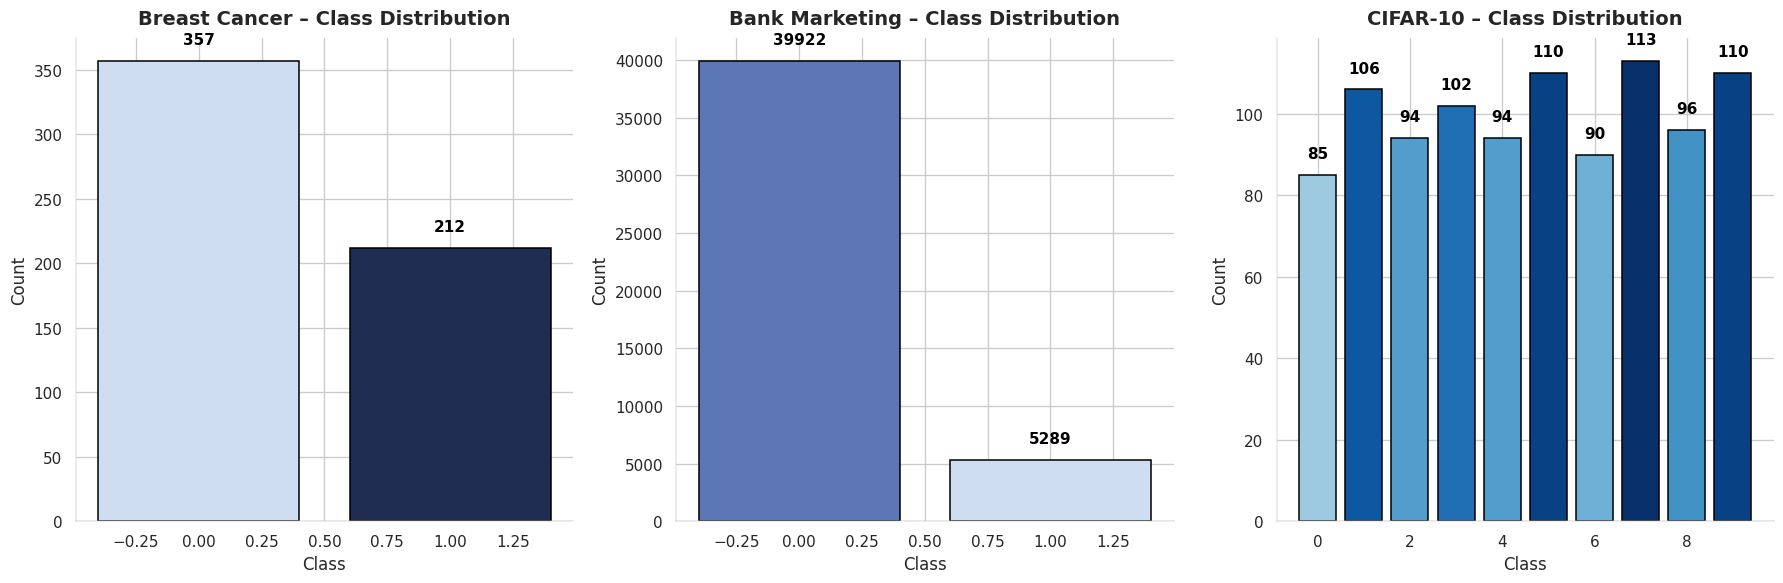

In [8]:


fig, axes = plt.subplots(1, 3, figsize=(18, 6))


#Breast class distribution

# Extract class distribution
classes, counts = np.unique(y_bc, return_counts=True)

ax = axes[0]

palette = {
     0: "#CEDEF0",   # Light Blue (Left Bar)
     1: "#1f2d52",   # Dark Slate Blue (Center Bar)
}
edgecolor = "black"

# Plot bars
bars = ax.bar(
    x=classes,
    height=counts,
    color=[palette[c] for c in classes],
    edgecolor=edgecolor,
    linewidth=1.1
)

# Add labels above bars
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + max(counts) * 0.03,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=edgecolor
    )

ax.set_title("Breast Cancer – Class Distribution", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.4)
ax.spines["bottom"].set_alpha(0.4)
ax.tick_params(axis="both", labelsize=11)


# Bank dataset class distribution

classes, counts = np.unique(y_bank, return_counts=True)

ax = axes[1]

palette = {
    0: "#5C76B6" ,  # Medium Slate Blue (Right Bar)
    1: "#CEDEF0",   # Light Blue (Left Bar)
}
edgecolor = "black"

bars = ax.bar(
    x=classes,
    height=counts,
    color=[palette[c] for c in classes],
    edgecolor=edgecolor,
    linewidth=1.1
)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + max(counts) * 0.03,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=edgecolor
    )

ax.set_title("Bank Marketing – Class Distribution", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.4)
ax.spines["bottom"].set_alpha(0.4)
ax.tick_params(axis="both", labelsize=11)


# CIFAR-10 class distribution

classes, counts = np.unique(y_cifar, return_counts=True)

ax = axes[2]

norm = mcolors.Normalize(vmin=min(counts) * 0.8, vmax=max(counts))
cmap = plt.get_cmap("Blues")

# Gradient colors based on counts
bar_colors = [cmap(norm(c)) for c in counts]

bars = ax.bar(
    x=classes,
    height=counts,
    color=bar_colors,
    edgecolor=edgecolor,
    linewidth=1.1
)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + max(counts) * 0.03,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=edgecolor
    )

ax.set_title("CIFAR-10 – Class Distribution", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.4)
ax.spines["bottom"].set_alpha(0.4)
ax.tick_params(axis="both", labelsize=11)


# Visualize class distributions
plt.tight_layout()
plt.savefig("results/dataset_class_distributions.png", dpi=300)
plt.show()

### Model Development and Evaluation

In [9]:
# Stability (Kuncheva Index)
from itertools import combinations

def kuncheva_index(set_a, set_b, total_features: int):
    """
    Kuncheva (consistency) index between two feature subsets.

    Ic(Si, Sj) = (|Si ∩ Sj| - k^2 / N) / (k - k^2 / N)
    where:
        N = total number of features
        k = subset size (assumed roughly equal here)
    """
    if total_features <= 0:
        return np.nan

    k_a = len(set_a)
    k_b = len(set_b)
    if k_a == 0 and k_b == 0:
        return 1.0

    # Use the smaller subset size if they differ slightly
    k = min(k_a, k_b)
    if k == 0:
        return 0.0

    intersection = len(set_a & set_b)
    numerator = intersection - (k * k) / total_features
    denominator = k - (k * k) / total_features

    if denominator == 0:
        # degenerate case, treat as perfect consistency if intersection matches
        return 1.0 if intersection == k else 0.0

    return numerator / denominator


def compute_stability(selected_sets, total_features: int):
    """
    selected_sets: list of sets of feature names, one per CV fold
    total_features: N (number of original features)
    returns: mean Kuncheva index over all pairwise combinations
    """
    if len(selected_sets) < 2:
        return np.nan

    indices = [
        kuncheva_index(s1, s2, total_features)
        for s1, s2 in combinations(selected_sets, 2)
    ]
    return float(np.mean(indices))


In [10]:
# Import the required libraries

#heuristic feature selector module
from heuristic_feature_selector import HeuristicFeatureSelector

# Define the Models Linear and Non Linear

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LDA": LinearDiscriminantAnalysis(),   
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_SEED
    ),
}

# Define the experiment parameters

results = []
f1_records = []
max_features = None
n_splits = 2
n_repeats = 1
random_state = 42

# Datasets

datasets = [
    {"name": "Breast Cancer", "X": X_bc, "y": y_bc, "use_smote": False},
    {"name": "Bank Marketing", "X": X_bank, "y": y_bank, "use_smote": True},
    {"name": "CIFAR-10", "X": X_cifar_df, "y": y_cifar, "use_smote": False},
]


In [11]:
# Experiment Looping

for ds in datasets:
    ds_name = ds["name"]
    X = ds["X"]
    y = np.asarray(ds["y"])
    use_smote = ds.get("use_smote", False)
    smote_kwargs = ds.get("smote_kwargs", {})

    n_classes = len(np.unique(y))
    is_binary = n_classes == 2

    for model_name, base_model in models.items():

        print(f"\n=== DATASET: {ds_name} | MODEL: {model_name} ===")

        # A) BASELINE (NO FEATURE SELECTION)
        
        accs = []; f1s = []; aucs = []
        fs_times = []; fit_times = []
        features_before = []; features_after = []
        selected_sets = []

        for rep in range(n_repeats):
            cv = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=random_state + rep
            )

            for train_idx, test_idx in cv.split(X, y):

                X_train = X.iloc[train_idx].copy()
                X_test = X.iloc[test_idx].copy()
                y_train = y[train_idx]
                y_test = y[test_idx]

                # Optional SMOTE
                if use_smote:
                    sm = SMOTE(random_state=random_state + rep, **smote_kwargs)
                    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
                else:
                    X_train_res, y_train_res = X_train, y_train

                # No feature selection
                t_fit_start = time.perf_counter()
                model_fold = base_model.__class__(**base_model.get_params())
                model_fold.fit(X_train_res, y_train_res)
                t_fit_end = time.perf_counter()

                fit_times.append(t_fit_end - t_fit_start)
                fs_times.append(0.0)

                y_pred = model_fold.predict(X_test)

                accs.append(accuracy_score(y_test, y_pred))
                f1_val = f1_score(y_test, y_pred,
                                 average="binary" if is_binary else "weighted")
                f1s.append(f1_val)

                # AUC
                if hasattr(model_fold, "predict_proba"):
                    y_proba = model_fold.predict_proba(X_test)
                    auc_val = (
                        roc_auc_score(y_test, y_proba[:, 1])
                        if is_binary else
                        roc_auc_score(y_test, y_proba, multi_class="ovr")
                    )
                    aucs.append(auc_val)
                else:
                    aucs.append(np.nan)

                features_before.append(X_train.shape[1])
                features_after.append(X_train.shape[1])

                f1_records.append({
                    "dataset": ds_name,
                    "model": model_name,
                    "fs_strategy": "none",
                    "sample_idx": len(f1_records),
                    "f1": f1_val,
                })

        # Summarize baseline
        results.append({
            "dataset": ds_name,
            "model": model_name,
            "fs_strategy": "none",
            "acc_mean": np.mean(accs),
            "acc_std": np.std(accs),
            "f1_mean": np.mean(f1s),
            "f1_std": np.std(f1s),
            "auc_mean": np.nanmean(aucs),
            "auc_std": np.nanstd(aucs),
            "fs_time_mean": np.mean(fs_times),
            "fit_time_mean": np.mean(fit_times),
            "n_features_before_mean": np.mean(features_before),
            "n_features_after_mean": np.mean(features_after),
            "stability": np.nan,
        })
      
# B) HEURISTIC FEATURE SELECTION
     
        accs = []; f1s = []; aucs = []
        fs_times = []; fit_times = []
        features_before = []; features_after = []
        selected_sets = []

        for rep in range(n_repeats):
            cv = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=random_state + rep
            )

            for train_idx, test_idx in cv.split(X, y):

                X_train = X.iloc[train_idx].copy()
                X_test = X.iloc[test_idx].copy()
                y_train = y[train_idx]
                y_test = y[test_idx]

                # Optional SMOTE
                if use_smote:
                    sm = SMOTE(random_state=random_state + rep, **smote_kwargs)
                    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
                else:
                    X_train_res, y_train_res = X_train, y_train

                # APPLY HEURISTIC FS
                hfs = HeuristicFeatureSelector(
                    max_features=max_features,
                    random_state=random_state + rep,
                    verbose=False
                )

                t_fs_start = time.perf_counter()
                result = hfs.fit_transform(X_train_res, y_train_res)
                t_fs_end = time.perf_counter()

                fs_time = result.fs_runtime if hasattr(result, "fs_runtime") else (t_fs_end - t_fs_start)

                fs_times.append(fs_time)
                selected_sets.append(set(result.selected_features))
                features_before.append(result.n_features_before)
                features_after.append(result.n_features_after)

                X_train_used = result.X_selected
                X_test_used = hfs.transform(X_test)

                # Train model
                t_fit_start = time.perf_counter()
                model_fold = base_model.__class__(**base_model.get_params())
                model_fold.fit(X_train_used, y_train_res)
                t_fit_end = time.perf_counter()
                fit_times.append(t_fit_end - t_fit_start)

                y_pred = model_fold.predict(X_test_used)

                accs.append(accuracy_score(y_test, y_pred))
                f1_val = f1_score(y_test, y_pred,
                                 average="binary" if is_binary else "weighted")
                f1s.append(f1_val)

                # AUC
                if hasattr(model_fold, "predict_proba"):
                    y_proba = model_fold.predict_proba(X_test_used)
                    auc_val = (
                        roc_auc_score(y_test, y_proba[:, 1])
                        if is_binary else
                        roc_auc_score(y_test, y_proba, multi_class="ovr")
                    )
                    aucs.append(auc_val)
                else:
                    aucs.append(np.nan)

                f1_records.append({
                    "dataset": ds_name,
                    "model": model_name,
                    "fs_strategy": "heuristic",
                    "sample_idx": len(f1_records),
                    "f1": f1_val,
                })

        stability = compute_stability(selected_sets, total_features=X.shape[1])

        results.append({
            "dataset": ds_name,
            "model": model_name,
            "fs_strategy": "heuristic",
            "acc_mean": np.mean(accs),
            "acc_std": np.std(accs),
            "f1_mean": np.mean(f1s),
            "f1_std": np.std(f1s),
            "auc_mean": np.nanmean(aucs),
            "auc_std": np.nanstd(aucs),
            "fs_time_mean": np.mean(fs_times),
            "fit_time_mean": np.mean(fit_times),
            "n_features_before_mean": np.mean(features_before),
            "n_features_after_mean": np.mean(features_after),
            "stability": stability,
        })



=== DATASET: Breast Cancer | MODEL: LogisticRegression ===

=== DATASET: Breast Cancer | MODEL: LDA ===

=== DATASET: Breast Cancer | MODEL: RandomForest ===

=== DATASET: Breast Cancer | MODEL: XGBoost ===

=== DATASET: Bank Marketing | MODEL: LogisticRegression ===

=== DATASET: Bank Marketing | MODEL: LDA ===

=== DATASET: Bank Marketing | MODEL: RandomForest ===

=== DATASET: Bank Marketing | MODEL: XGBoost ===

=== DATASET: CIFAR-10 | MODEL: LogisticRegression ===

=== DATASET: CIFAR-10 | MODEL: LDA ===

=== DATASET: CIFAR-10 | MODEL: RandomForest ===

=== DATASET: CIFAR-10 | MODEL: XGBoost ===


In [12]:
# Results
results_df = pd.DataFrame(results)
f1_long_df =pd.DataFrame(f1_records)

results_df.to_csv("results/results.csv", index=False)
f1_long_df.to_csv("results/f1_records.csv", index=False)
results_df.tail(10)

,dataset,model,fs_strategy,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std,fs_time_mean,fit_time_mean,n_features_before_mean,n_features_after_mean,stability
14,Bank Marketing,XGBoost,none,0.902236,0.000219,0.582594,0.004097,0.925059,0.000817,0.000000,6.897227,47.0,47.0,NaN
15,Bank Marketing,XGBoost,heuristic,0.863374,0.004139,0.306185,0.015061,0.676659,0.005934,22.839279,14.363554,47.0,30.0,1.000000
16,CIFAR-10,LogisticRegression,none,0.293000,0.003000,0.294703,0.000384,0.724242,0.004996,0.000000,70.455556,3072.0,3072.0,NaN
17,CIFAR-10,LogisticRegression,heuristic,0.230000,0.004000,0.219211,0.004464,0.665900,0.011106,11.422198,7.454644,3072.0,153.0,0.594167
18,CIFAR-10,LDA,none,0.191000,0.009000,0.190228,0.006711,0.627461,0.000307,0.000000,3.314976,3072.0,3072.0,NaN
19,CIFAR-10,LDA,heuristic,0.177000,0.025000,0.172267,0.021663,0.602933,0.010287,11.711267,0.214814,3072.0,153.0,0.594167
20,CIFAR-10,RandomForest,none,0.346000,0.020000,0.339742,0.021431,0.767354,0.018252,0.000000,3.745624,3072.0,3072.0,NaN
21,CIFAR-10,RandomForest,heuristic,0.240000,0.006000,0.232477,0.001319,0.695872,0.006056,11.239349,1.120004,3072.0,153.0,0.594167
22,CIFAR-10,XGBoost,none,0.325000,0.031000,0.320554,0.030412,0.756941,0.011080,0.000000,77.482566,3072.0,3072.0,NaN
23,CIFAR-10,XGBoost,heuristic,0.225000,0.003000,0.221782,0.000193,0.675556,0.004402,11.188466,20.660983,3072.0,153.0,0.594167


### Visualize the results

,dataset,model,fs_strategy,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std,fs_time_mean,fit_time_mean,n_features_before_mean,n_features_after_mean,stability
0,Breast Cancer,LogisticRegression,none,0.971905,0.014010,0.961258,0.019511,0.994065,0.003815,0.0,0.006192,30.0,30.0,NaN
2,Breast Cancer,LDA,none,0.954312,0.003435,0.935347,0.004653,0.991184,0.003463,0.0,0.002741,30.0,30.0,NaN
4,Breast Cancer,RandomForest,none,0.956072,0.005195,0.940030,0.007338,0.985613,0.005351,0.0,0.349479,30.0,30.0,NaN
6,Breast Cancer,XGBoost,none,0.957839,0.010471,0.942788,0.014558,0.988573,0.005597,0.0,0.360192,30.0,30.0,NaN
8,Bank Marketing,LogisticRegression,none,0.894871,0.000290,0.528233,0.002274,0.888301,0.000431,0.0,5.302027,47.0,47.0,NaN


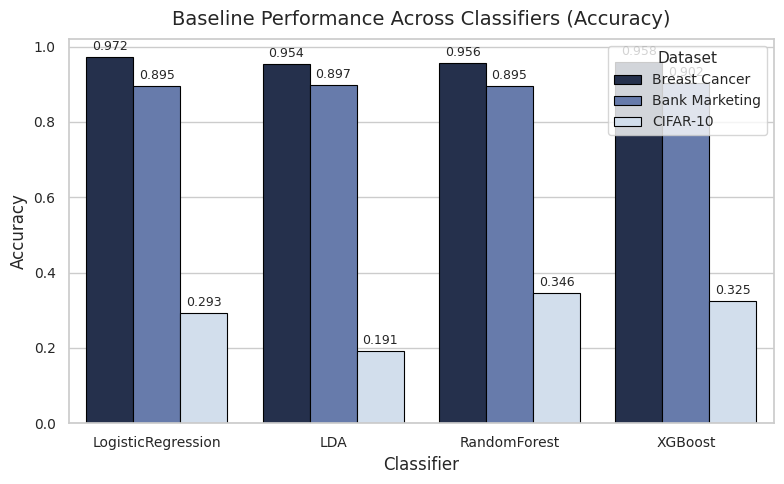

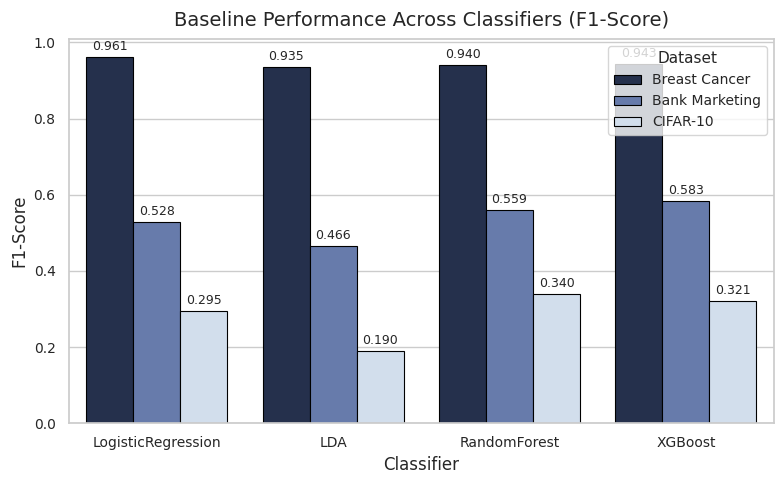

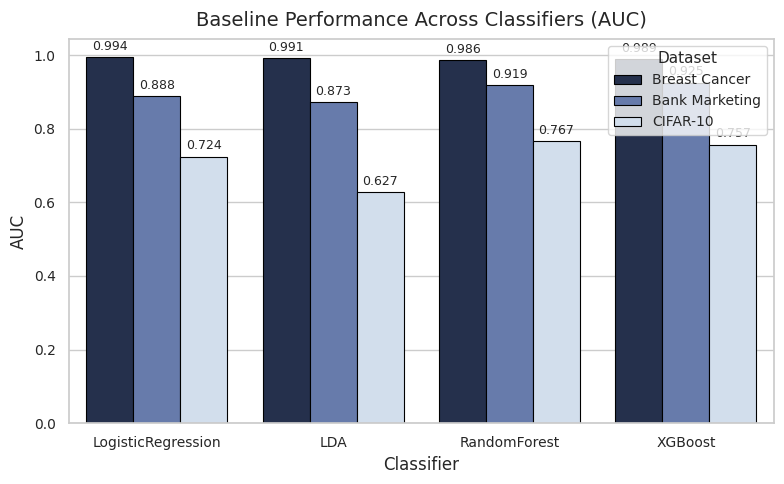

In [13]:
# Baseline Performance Comparison Across Classifiers Figure 4.5

df_base = results_df[results_df["fs_strategy"] == "none"].copy()

if df_base.empty:
    print("No baseline rows found.")
else:
    display(df_base.head())

metric_labels = [
    ("acc_mean", "Accuracy"),
    ("f1_mean", "F1-Score"),
    ("auc_mean", "AUC"),
]

palette = {
    "Breast Cancer": "#1f2d52",   # Dark Slate Blue (Center Bar)
    "Bank Marketing": "#5C76B6" ,  # Medium Slate Blue (Right Bar)
    "CIFAR-10": "#CEDEF0",   # Light Blue (Left Bar)
}
edgecolor = "black"

for metric, ylabel in metric_labels:

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        data=df_base,
        x="model",
        y=metric,
        hue="dataset",
        palette=palette,
        edgecolor=edgecolor,
        linewidth=0.8
    )

    # Add numerical labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3,
            fontsize=9
        )

    plt.title(
        f"Baseline Performance Across Classifiers ({ylabel})",
        fontsize=14,
        pad=10
    )
    plt.xlabel("Classifier", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    plt.legend(title="Dataset", fontsize=10, title_fontsize=11)

    plt.xticks(rotation=0, fontsize=10)
    plt.yticks(fontsize=10)

    plt.tight_layout()
    plt.savefig(f"results/baseline_{metric}.png")
    plt.show()



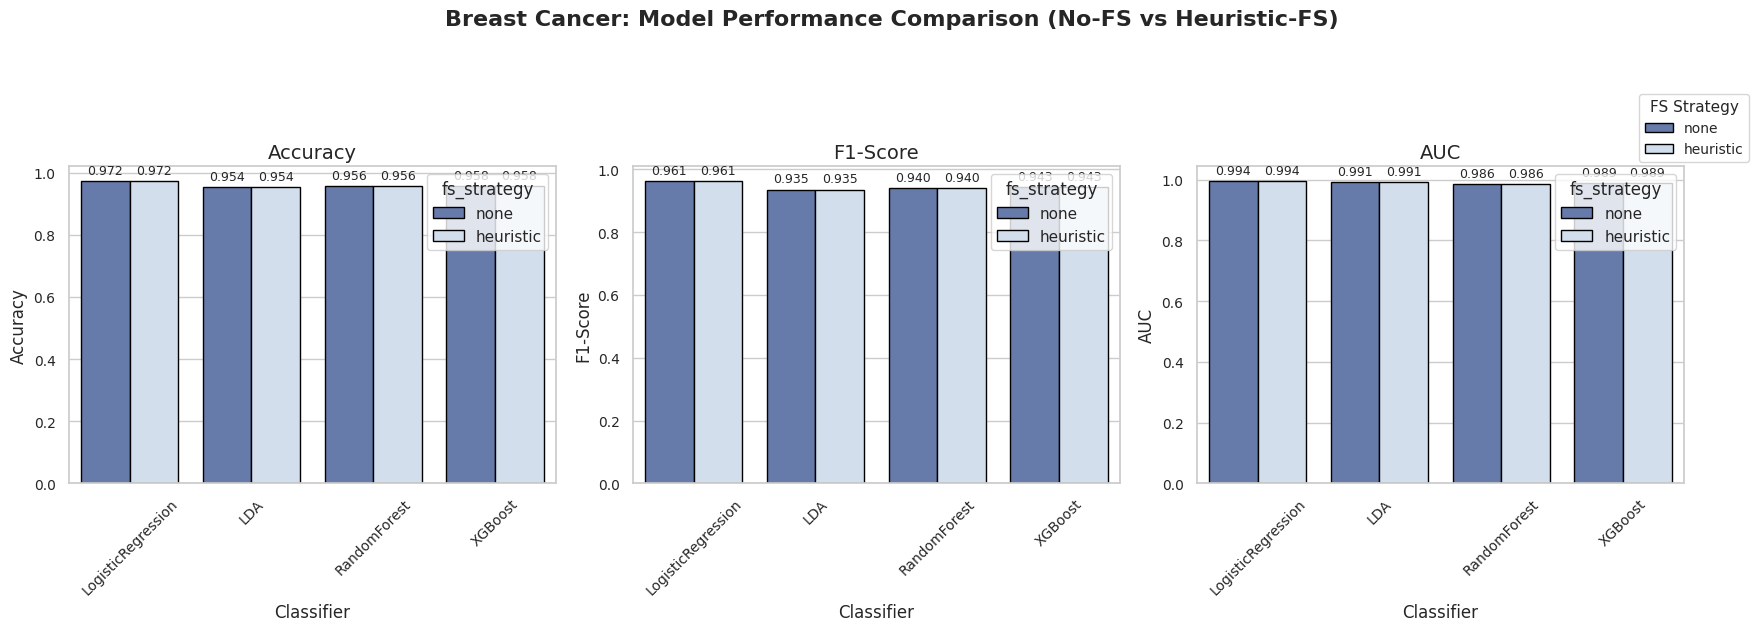

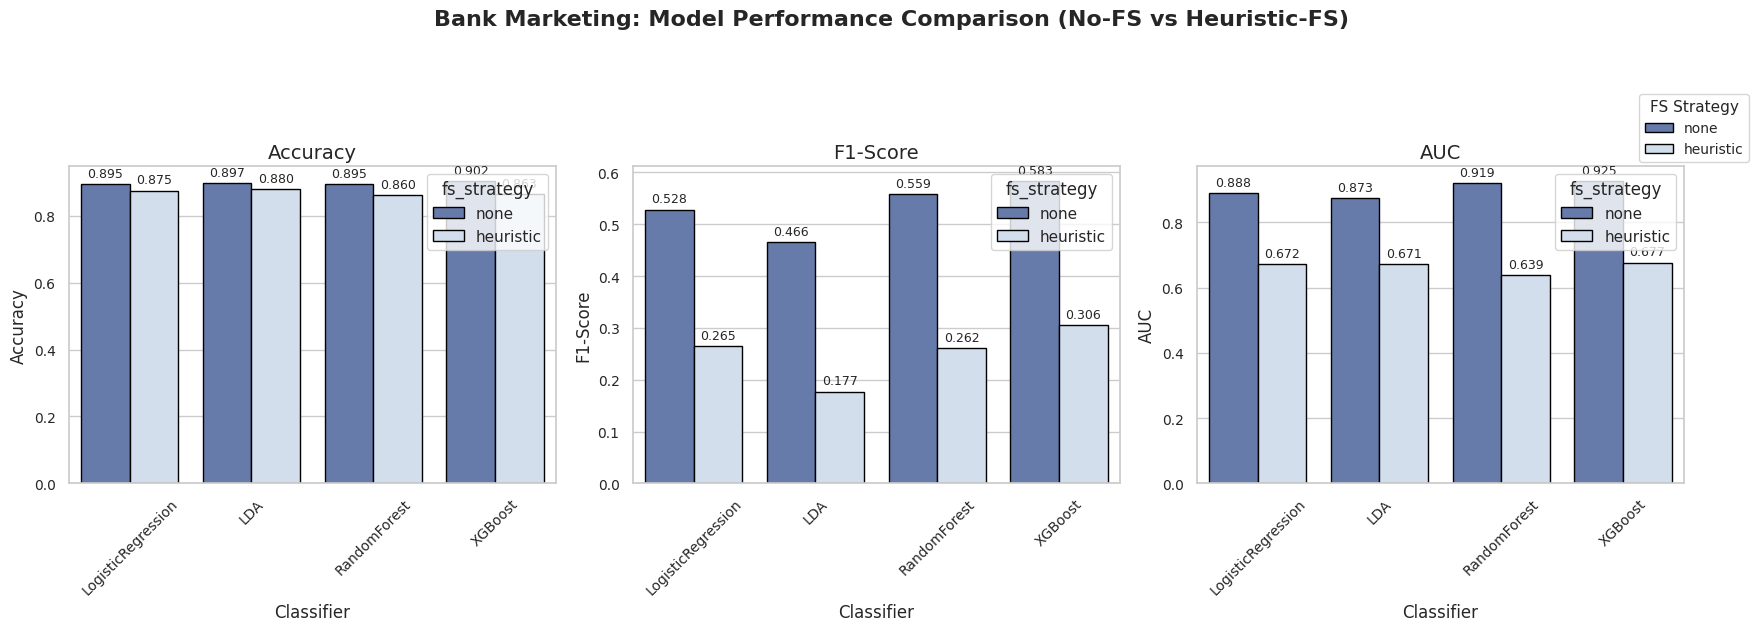

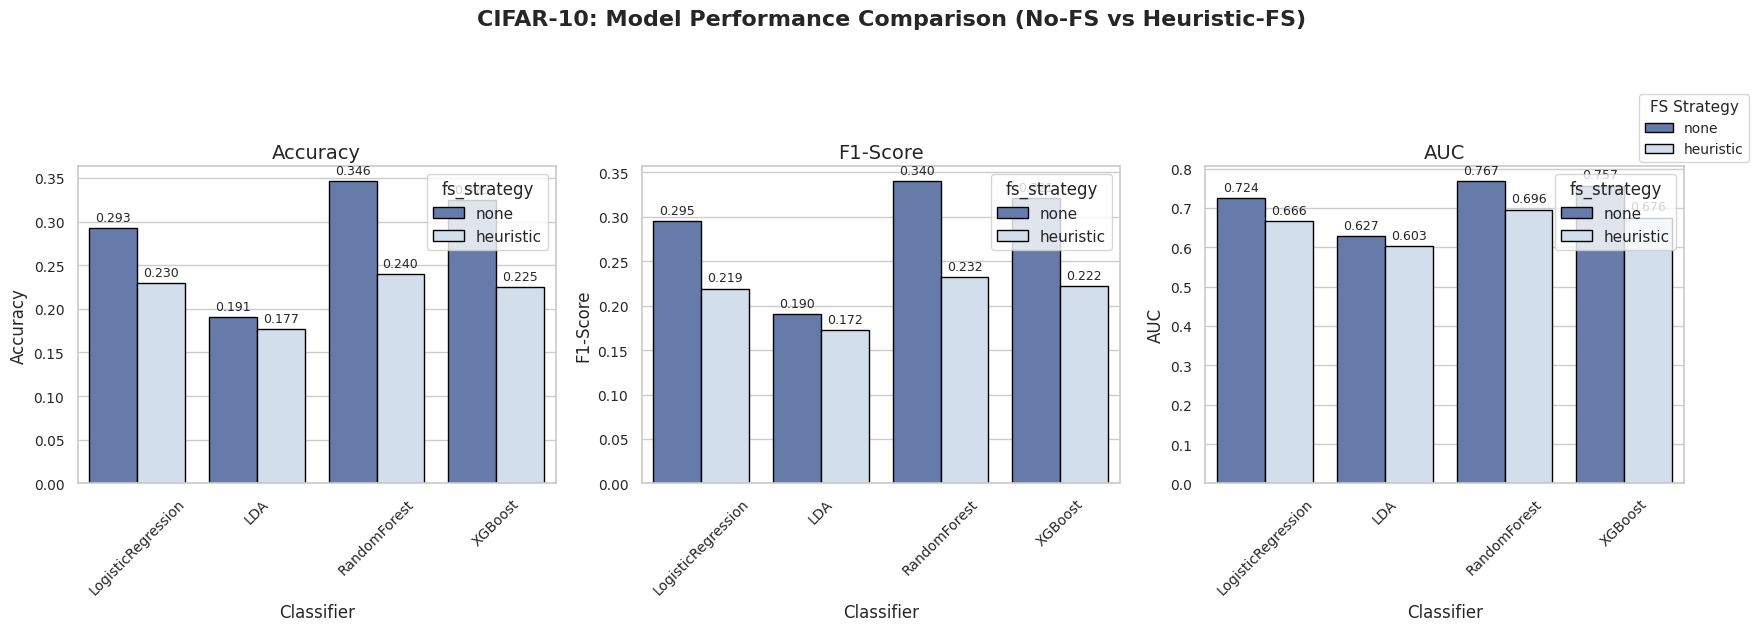

In [14]:

#Combined Performance Plots One Figure per datasets

metrics = [
    ("acc_mean", "Accuracy"),
    ("f1_mean",  "F1-Score"),
    ("auc_mean", "AUC"),
]

palette = {
    "none": "#5C76B6" ,  # Medium Slate Blue (Right Bar)
    "heuristic": "#CEDEF0",   # Light Blue (Left Bar)
}
edgecolor = "black"

for ds_name in results_df["dataset"].unique():

    df_ds = results_df[results_df["dataset"] == ds_name]
    if df_ds.empty:
        continue

    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

    fig.suptitle(
        f"{ds_name}: Model Performance Comparison (No-FS vs Heuristic-FS)",
        fontsize=16,
        weight="bold",
        y=1.05
    )

    # Loop through Accuracy, F1, AUC
    for ax, (metric, ylabel) in zip(axes, metrics):

        sns.barplot(
            data=df_ds,
            x="model",
            y=metric,
            hue="fs_strategy",
            palette=palette,
            edgecolor=edgecolor,
            linewidth=1.0,
            ax=ax,
        )

        # Add numeric labels
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

        ax.set_title(ylabel, fontsize=14)
        ax.set_xlabel("Classifier", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)

        ax.tick_params(axis="x", rotation=45, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)

    # Shared Legend (only once per dataset)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="FS Strategy",
        fontsize=10,
        title_fontsize=11,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.92)
    )

    plt.tight_layout(rect=[0, 0, 0.95, 0.92])
    plt.savefig(f"results/{ds_name}_performance_comparison.png")
    plt.show()



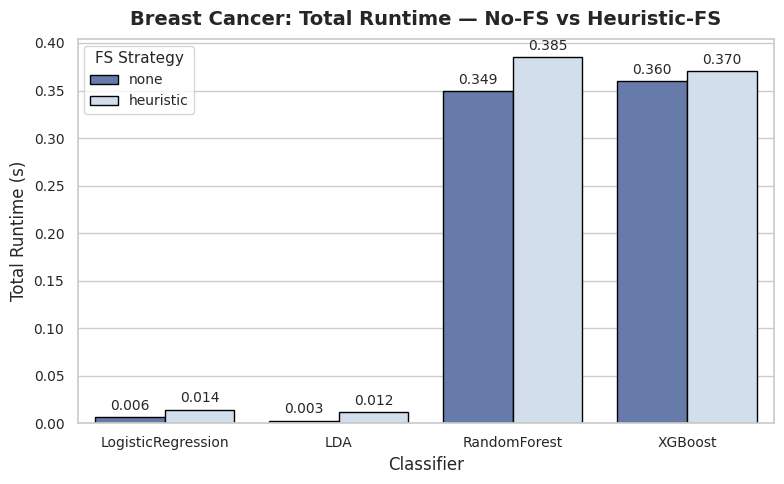

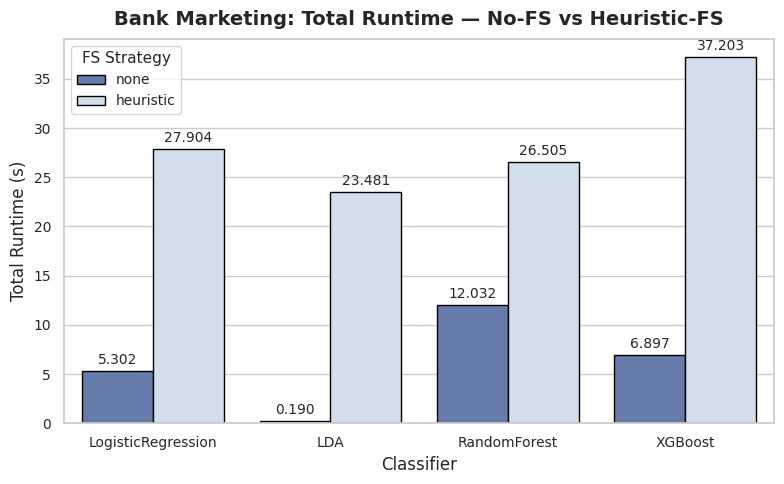

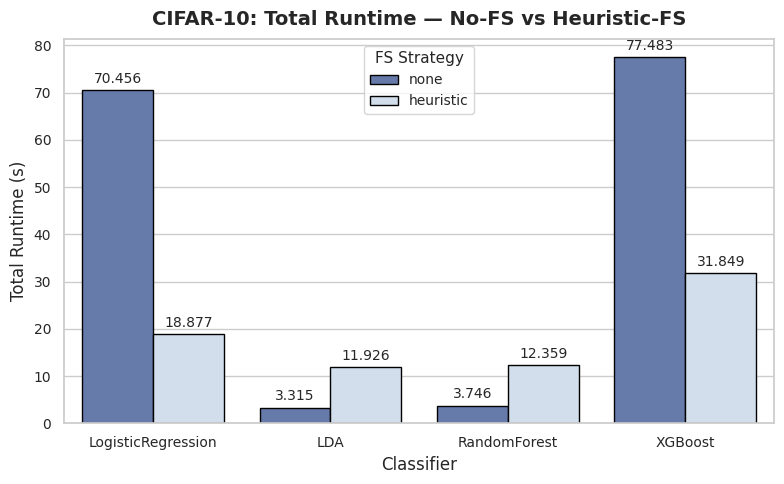

In [15]:
#Runtime Plots One Figure per datasets

palette = {
    "none": "#5C76B6",  # Medium Slate Blue (Right Bar)
    "heuristic": "#CEDEF0",  # Light Blue (Left Bar)
}
edgecolor = "black"

df_runtime = results_df.copy()
df_runtime["total_runtime_mean"] = (
    df_runtime["fs_time_mean"] + df_runtime["fit_time_mean"]
)

df_runtime.head()

unique_datasets = df_runtime["dataset"].unique()
unique_datasets

for ds_name in unique_datasets:

    df_ds = df_runtime[df_runtime["dataset"] == ds_name]

    if df_ds.empty:
        continue

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        data=df_ds,
        x="model",
        y="total_runtime_mean",
        hue="fs_strategy",
        palette=palette,        
        edgecolor=edgecolor,   
        linewidth=1.0
    )

    # Add numeric labels on top of bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3,
            fontsize=10
        )

    plt.title(
        f"{ds_name}: Total Runtime — No-FS vs Heuristic-FS",
        fontsize=14,
        weight="bold",
        pad=10
    )

    plt.xlabel("Classifier", fontsize=12)
    plt.ylabel("Total Runtime (s)", fontsize=12)

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.legend(
        title="FS Strategy",
        fontsize=10,
        title_fontsize=11
    )

    plt.tight_layout()
    plt.savefig(f"results/{ds_name}_runtime_comparison.png")
    plt.show()


,dataset,model,fs_strategy,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std,fs_time_mean,fit_time_mean,n_features_before_mean,n_features_after_mean,stability
1,Breast Cancer,LogisticRegression,heuristic,0.971905,0.014010,0.961258,0.019511,0.994065,0.003815,0.009753,0.004667,30.0,30.0,1.0
3,Breast Cancer,LDA,heuristic,0.954312,0.003435,0.935347,0.004653,0.991184,0.003463,0.009296,0.002753,30.0,30.0,1.0
5,Breast Cancer,RandomForest,heuristic,0.956072,0.005195,0.940030,0.007338,0.985613,0.005351,0.012957,0.372104,30.0,30.0,1.0
7,Breast Cancer,XGBoost,heuristic,0.957839,0.010471,0.942788,0.014558,0.988573,0.005597,0.063199,0.306901,30.0,30.0,1.0
9,Bank Marketing,LogisticRegression,heuristic,0.874942,0.000395,0.265331,0.002721,0.671524,0.005720,25.016417,2.887361,47.0,30.0,1.0


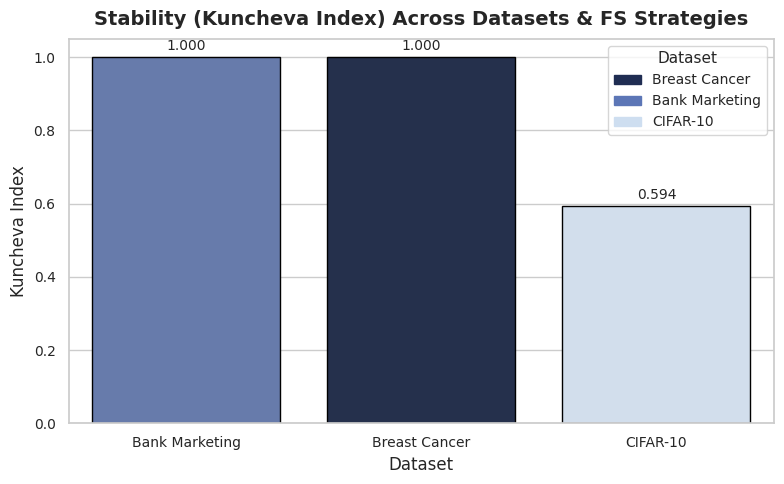

In [16]:
# Stability

palette = {
    "Breast Cancer": "#1f2d52",     # Dark Slate Blue
    "Bank Marketing": "#5C76B6",    # Medium Slate Blue
    "CIFAR-10": "#CEDEF0",          # Light Blue
}
edgecolor = "black"

df_stab = results_df.copy()
df_stab = df_stab.dropna(subset=["stability"])   

if df_stab.empty:
    print("No stability values available — did you compute Kuncheva Index?")
else:
    display(df_stab.head())

df_stab_agg = (
    df_stab.groupby(["dataset", "fs_strategy"], as_index=False)["stability"]
           .mean()
)

df_stab_agg

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_stab_agg,
    x="dataset",
    y="stability",
    # hue="fs_strategy",
    palette=palette,
    edgecolor=edgecolor,
    linewidth=1.0
)

# Add numeric labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=10
    )

plt.title(
    "Stability (Kuncheva Index) Across Datasets & FS Strategies",
    fontsize=14,
    weight="bold",
    pad=10
)

plt.xlabel("Dataset", fontsize=12)
plt.ylabel("Kuncheva Index", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

legend_handles = [
    mpatches.Patch(color=palette["Breast Cancer"], label="Breast Cancer"),
    mpatches.Patch(color=palette["Bank Marketing"], label="Bank Marketing"),
    mpatches.Patch(color=palette["CIFAR-10"], label="CIFAR-10"),
]

plt.legend(
    handles=legend_handles,
    title="Dataset",
    fontsize=10,
    title_fontsize=11,
    loc="upper right"
)


plt.tight_layout()
plt.savefig("results/stability_comparison.png")
plt.show()




In [17]:

# ANOVA Test
from scipy.stats import f_oneway, ttest_rel

anova_records = []

for ds_name in f1_long_df["dataset"].unique():

    sub = f1_long_df[f1_long_df["dataset"] == ds_name]

    # Extract F1 values
    f1_none = sub[sub["fs_strategy"] == "none"]["f1"].values
    f1_heuristic = sub[sub["fs_strategy"] == "heuristic"]["f1"].values

    # 1-way ANOVA
    F_stat, p_value = f_oneway(f1_none, f1_heuristic)

    anova_records.append({
        "dataset": ds_name,
        "F_statistic": F_stat,
        "p_value": p_value,
        "significant_0_05": p_value < 0.05,
    })


anova_df = pd.DataFrame(anova_records)
anova_df

anova_df.to_csv("results/anova_results.csv", index=False)


In [18]:
# Paired t-test
ttest_rows = []

for ds_name in f1_long_df["dataset"].unique():
    for model_name in f1_long_df["model"].unique():

        sub = f1_long_df[
            (f1_long_df["dataset"] == ds_name) &
            (f1_long_df["model"] == model_name)
        ]

        if sub["fs_strategy"].nunique() < 2:
            continue

        # Extract sorted F1 samples
        f1_none = sub[sub["fs_strategy"] == "none"]["f1"].sort_values().values
        f1_heuristic = sub[sub["fs_strategy"] == "heuristic"]["f1"].sort_values().values

        # Ensure equal sample length
        k = min(len(f1_none), len(f1_heuristic))
        f1_none = f1_none[:k]
        f1_heuristic = f1_heuristic[:k]

        # Paired t-test
        t_stat, p_val = ttest_rel(f1_none, f1_heuristic)

                # Handle nan cases (identical arrays)
                if np.isnan(t_stat):
                    t_stat = 0.0
                    p_val = 1.0

        # Cohen's d: effect size
        diff = f1_heuristic - f1_none
        if diff.std(ddof=1) > 0:
            cohen_d = diff.mean() / diff.std(ddof=1)
        else:
            cohen_d = 0.0

        ttest_rows.append({
            "dataset": ds_name,
            "model": model_name,
            "comparison": "heuristic vs none",
            "t_statistic": t_stat,
            "p_value": p_val,
            "significant_0_05": p_val < 0.05,
            "cohen_d": cohen_d,
        })

# Convert to DataFrame
ttest_df = pd.DataFrame(ttest_rows)
ttest_df.to_csv("results/ttest_results.csv", index=False)

ttest_df


,dataset,model,comparison,t_statistic,p_value,significant_0_05,cohen_d
0,Breast Cancer,LogisticRegression,heuristic vs none,NaN,NaN,False,NaN
1,Breast Cancer,LDA,heuristic vs none,NaN,NaN,False,NaN
2,Breast Cancer,RandomForest,heuristic vs none,NaN,NaN,False,NaN
3,Breast Cancer,XGBoost,heuristic vs none,NaN,NaN,False,NaN
4,Bank Marketing,LogisticRegression,heuristic vs none,588.063297,0.001083,True,-415.823545
5,Bank Marketing,LDA,heuristic vs none,111.060488,0.005732,True,-78.531624
6,Bank Marketing,RandomForest,heuristic vs none,282.063980,0.002257,True,-199.449353
7,Bank Marketing,XGBoost,heuristic vs none,25.212356,0.025237,True,-17.827828
8,CIFAR-10,LogisticRegression,heuristic vs none,18.502572,0.034374,True,-13.083294
9,CIFAR-10,LDA,heuristic vs none,1.201205,0.441970,False,-0.849380


# SHAP Importance

In [19]:
# Choose performance metric (F1 recommended)
metric = "f1_mean"

best_models = {}

for ds_name in results_df["dataset"].unique():

    best_models[ds_name] = {}

    df_ds = results_df[results_df["dataset"] == ds_name]

    # Best No-FS model
    df_none = df_ds[df_ds["fs_strategy"] == "none"]
    best_none = df_none.loc[df_none[metric].idxmax()]
    best_models[ds_name]["none"] = {
        "model_name": best_none["model"],
        "score": best_none[metric]
    }

    # Best Heuristic-FS model
    df_fs = df_ds[df_ds["fs_strategy"] == "heuristic"]
    best_fs = df_fs.loc[df_fs[metric].idxmax()]
    best_models[ds_name]["heuristic"] = {
        "model_name": best_fs["model"],
        "score": best_fs[metric]
    }

best_models



{'Breast Cancer': {'none': {'model_name': 'LogisticRegression',
   'score': 0.9612584017923824},
  'heuristic': {'model_name': 'LogisticRegression',
   'score': 0.9612584017923824}},
 'Bank Marketing': {'none': {'model_name': 'XGBoost',
   'score': 0.5825941643474284},
  'heuristic': {'model_name': 'XGBoost', 'score': 0.30618499707171276}},
 'CIFAR-10': {'none': {'model_name': 'RandomForest',
   'score': 0.3397419777279219},
  'heuristic': {'model_name': 'RandomForest', 'score': 0.23247740746768097}}}

In [20]:
# Model Lookup
model_lookup = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LDA": LinearDiscriminantAnalysis(),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}


In [21]:
# Prepare X based on the selected strategy
def prepare_X_for_strategy(X, y, strategy):
    if strategy == "none":
        return X

    hfs = HeuristicFeatureSelector(max_features=20)
    res = hfs.fit_transform(X, y)
    return res.X_selected


In [22]:
def get_shap_values(model, X, y):
    # Check for XGBoost and update params for multiclass if needed
    if "XGBClassifier" in model.__class__.__name__:
        n_classes = len(np.unique(y))
        if n_classes > 2:
            model.set_params(num_class=n_classes, objective="multi:softprob", eval_metric="mlogloss")
        else:
            model.set_params(num_class=None, objective="binary:logistic", eval_metric="logloss")

    model.fit(X, y)
    name = model.__class__.__name__.lower()

    if "forest" in name or "tree" in name or "xgb" in name:
        explainer = shap.TreeExplainer(model)
        vals = explainer.shap_values(X)
    elif "logistic" in name or "linear" in name:
        explainer = shap.LinearExplainer(model, X)
        vals = explainer.shap_values(X)
    else:
        background = X.sample(min(100, len(X)), random_state=42)
        explainer = shap.KernelExplainer(model.predict_proba, background)
        vals = explainer.shap_values(X)

    # Binary → pick class 1
    if isinstance(vals, list):
        return vals[1] if len(vals) > 1 else vals[0]

    return vals


In [23]:
# plot the Top 15 SHAP features
def plot_shap_top15(model_name, ds_name, X, shap_vals):
    mean_abs = np.abs(shap_vals).mean(axis=0)
    if mean_abs.ndim > 1:
        mean_abs = mean_abs.sum(axis=1)

    df = (
        pd.DataFrame({"feature": X.columns, "importance": mean_abs})
        .sort_values("importance", ascending=False)
        .head(15)
        .iloc[::-1]
    )

    # Compute percentages
    total = df["importance"].sum()
    df["pct"] = df["importance"] / total * 100

    plt.figure(figsize=(8, 7))
    norm = plt.Normalize(df["importance"].min(), df["importance"].max())
    cmap = plt.get_cmap("Blues")

    bars = plt.barh(
        df["feature"],
        df["importance"],
        color=cmap(norm(df["importance"])),
        edgecolor="black",
        linewidth=1.2
    )

    # Add percentage labels
    for bar, pct in zip(bars, df["pct"]):
        plt.text(
            bar.get_width() + (df["importance"].max() * 0.01),  
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="black"
        )

    plt.title(
        f"{ds_name} — {model_name}: Top-15 SHAP Features",
        fontsize=14,
        weight="bold"
    )

    plt.xlabel("Mean |SHAP Value|")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.savefig(f"results/{ds_name}_{model_name}_shap_top15.png")
    plt.show()


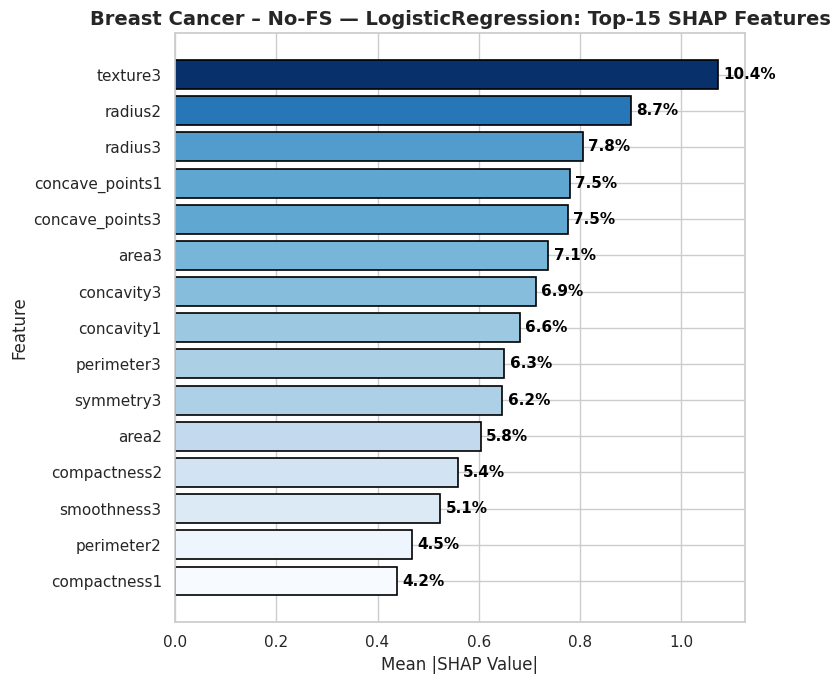

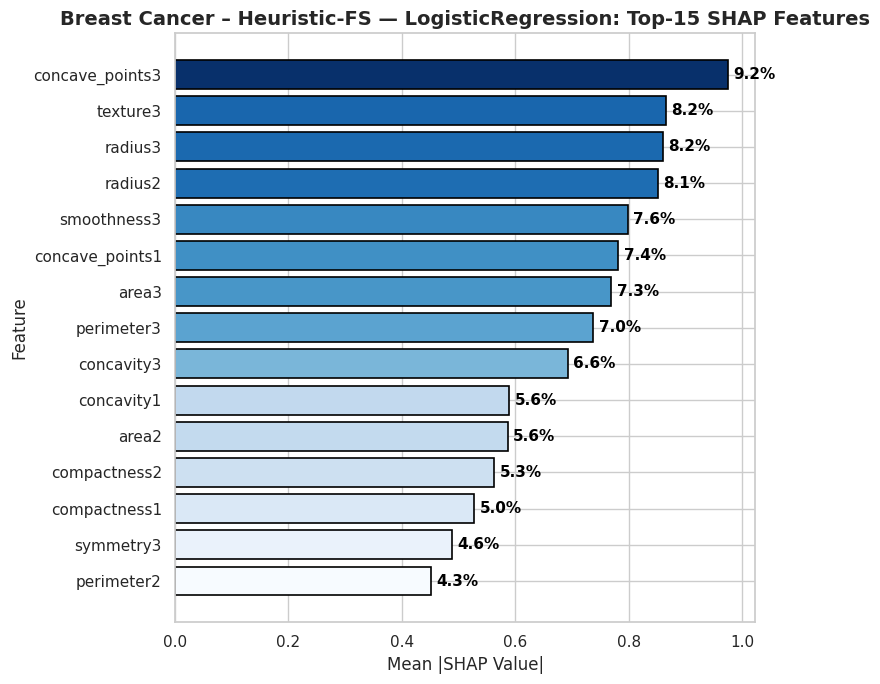

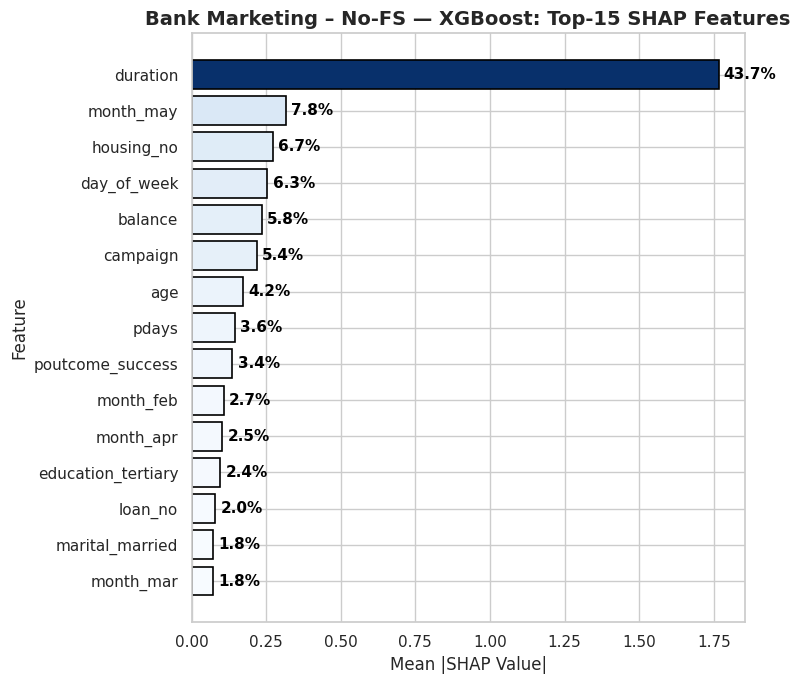

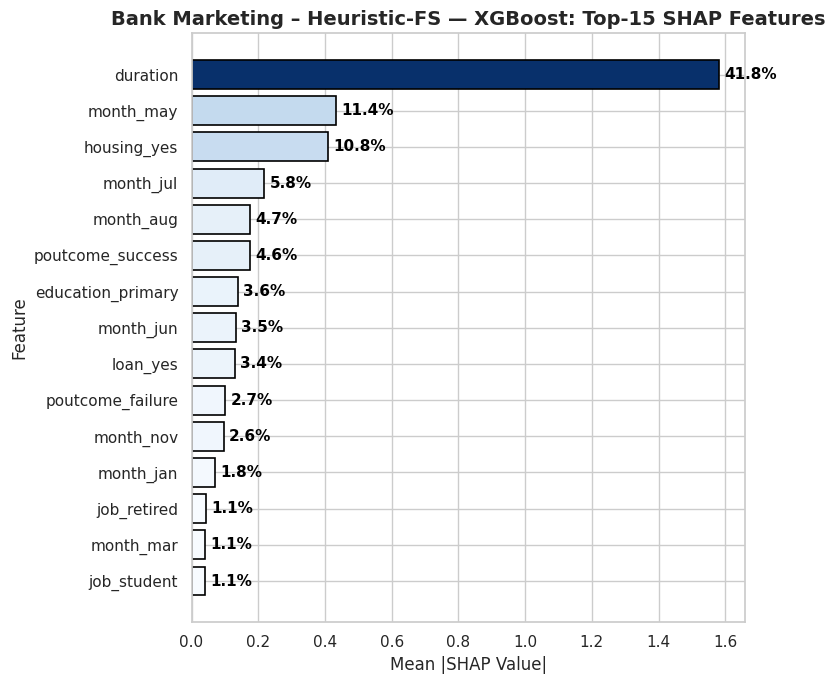

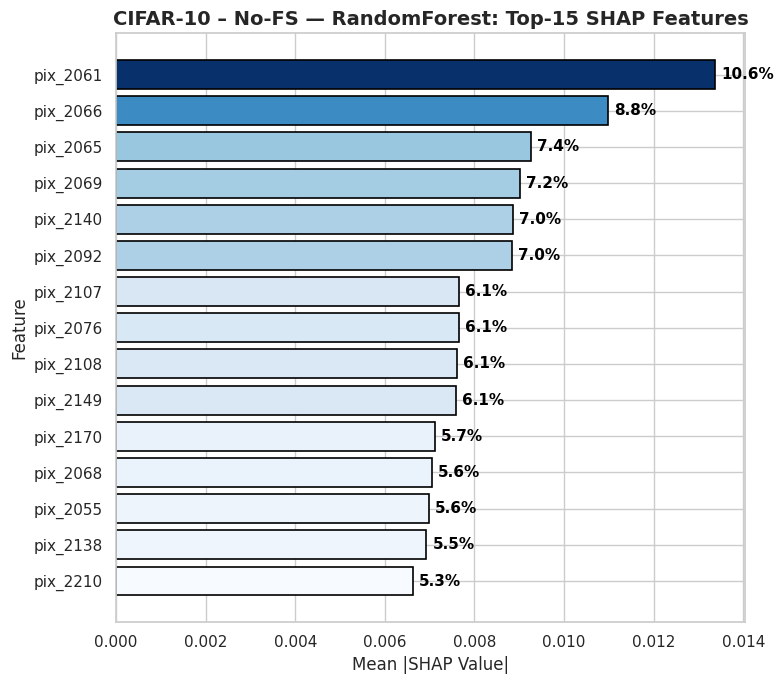

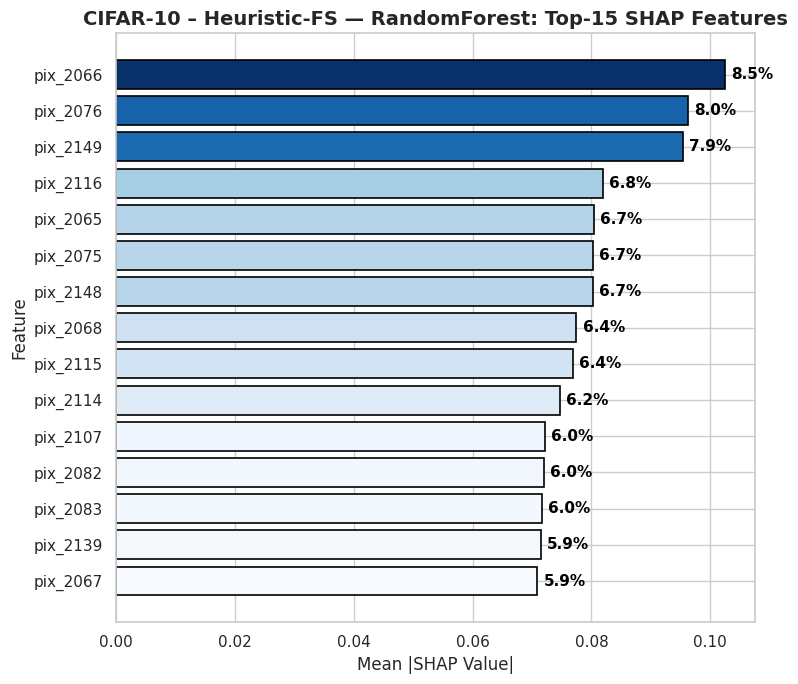

In [24]:
# --- Load Data ---
datasets_lookup = {
    "Breast Cancer": (X_bc, y_bc),
    "Bank Marketing": (X_bank, y_bank),
    "CIFAR-10": (X_cifar_df, y_cifar),
}


# --- Plot SHAP ---
for ds_name, info in best_models.items():

    X_orig, y_orig = datasets_lookup[ds_name]

    # --- No-FS ---
    best_none_model_name = info["none"]["model_name"]
    model_none = model_lookup[best_none_model_name]

    X_none = prepare_X_for_strategy(X_orig, y_orig, "none")
    shap_none = get_shap_values(model_none, X_none, y_orig)

    plot_shap_top15(best_none_model_name, f"{ds_name} – No-FS", X_none, shap_none)

    # --- Heuristic-FS ---
    best_fs_model_name = info["heuristic"]["model_name"]
    model_fs = model_lookup[best_fs_model_name]

    X_fs = prepare_X_for_strategy(X_orig, y_orig, "heuristic")
    shap_fs = get_shap_values(model_fs, X_fs, y_orig)

    plot_shap_top15(best_fs_model_name, f"{ds_name} – Heuristic-FS", X_fs, shap_fs)
